# A 股宇宙构建

**目标**：为 A 股截面选股研究构建可靠的股票宇宙。

**核心挑战**：A 股宇宙构建远比 S&P 500 复杂——需要处理 ST 股、新股锁定期、停牌，以及最关键的 point-in-time 问题（不能用未来才知道的信息构建历史宇宙）。

**数据来源组合**：
| 数据 | 来源 | 原因 |
|---|---|---|
| OHLCV 行情 + 复权因子 | Tushare | 质量可靠，接口稳定 |
| 交易日历 | AKShare | Tushare 需要 2000 积分 |
| 股票基本信息（上市日期）| AKShare | Tushare 需要 2000 积分 |
| CSI 500 成分股 | AKShare | Tushare `index_weight` 需要高积分 |
| ST 历史 | Tushare `namechange` | AKShare 无历史 ST 记录 |


## 1. 环境初始化

In [15]:
from __future__ import annotations
import sys, os
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sp500_relative_alpha.ashare_data_loader import (
    load_ashare_trading_calendar,
    load_csi500_universe,
    load_stock_basic,
    load_st_history,
    build_daily_universe,
)

%matplotlib inline
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.family"] = "Arial Unicode MS"
plt.rcParams["axes.unicode_minus"] = False

## 2. 交易日历

A 股有独特的交易日历——春节、国庆等长假导致连续多个非交易日。
所有日期计算（上市天数、purge gap）必须基于实际交易日，而不是自然日。


交易日总数：3214
日期范围：2013-01-04 ~ 2026-04-01


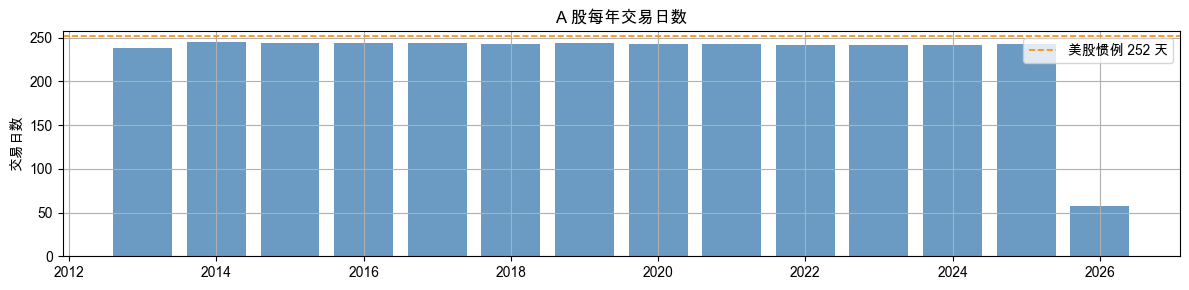

In [16]:
calendar = load_ashare_trading_calendar()

print(f"交易日总数：{len(calendar)}")
print(f"日期范围：{calendar[0].date()} ~ {calendar[-1].date()}")

# 每年交易日数
yearly = pd.Series(1, index=calendar).resample("YE").count()
fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(yearly.index.year, yearly.values, color="steelblue", alpha=0.8)
ax.axhline(252, color="darkorange", lw=1.2, linestyle="--", label="美股惯例 252 天")
ax.set_title("A 股每年交易日数")
ax.set_ylabel("交易日数")
ax.legend()
plt.tight_layout()
plt.show()


In [17]:
# 每月第一个交易日，研究期 2015-2026，全局复用
cal_series = pd.Series(calendar, index=calendar)
sample_dates = pd.DatetimeIndex(
    cal_series.resample("ME").first().dropna().values
)
sample_dates = sample_dates[(sample_dates >= "2015-01-01") & (sample_dates <= "2026-01-01")]
print(f"截面日数量：{len(sample_dates)}，范围：{sample_dates[0].date()} ~ {sample_dates[-1].date()}")

截面日数量：132，范围：2015-01-05 ~ 2025-12-01


## 3. CSI 500 宇宙候选

**为什么选 CSI 500（中证500）而非 CSI 300？**

| 指数 | 成分股 | 特点 |
|---|---|---|
| CSI 300 | 大盘股 | 机构持仓集中，市场效率高，alpha 较难挖掘 |
| **CSI 500** | **中盘股** | 研究覆盖相对少，散户参与多，量价信号效果更好 |
| CSI 1000 | 小盘股 | 流动性差，交易成本高，不适合实盘 |

**Point-in-time 近似**：AKShare 只提供纳入日期，无退出日期。
处理方式：曾纳入 CSI 500 的股票在研究期内保留为候选，配合上市日/ST/停牌过滤。


In [18]:
universe = load_csi500_universe()
print(f"CSI 500 候选股票：{len(universe)} 只")
print(f"有纳入日期记录：{universe['in_date'].notna().sum()} 只")
print(universe.head(5).to_string())


CSI 500 候选股票：500 只
有纳入日期记录：0 只
      symbol  name in_date
0  000009.SZ  中国宝安     NaT
1  000021.SZ   深科技     NaT
2  000027.SZ  深圳能源     NaT
3  000032.SZ  深桑达A     NaT
4  000034.SZ  神州数码     NaT


## 4. 股票基本信息（上市日期）

**为什么要过滤新股？**

新上市股票存在以下问题：
1. 历史太短，技术指标（如 `ret_252d`）无法计算
2. IPO 后1年内价格波动受新股效应主导，不反映基本面或量价规律
3. 破发/上涨极端行情会污染截面信号

**过滤规则**：`list_date + 252 个交易日 < signal_date`


全市场股票：5199 只
  沪市（.SH）：2311 只
  深市（.SZ）：2888 只


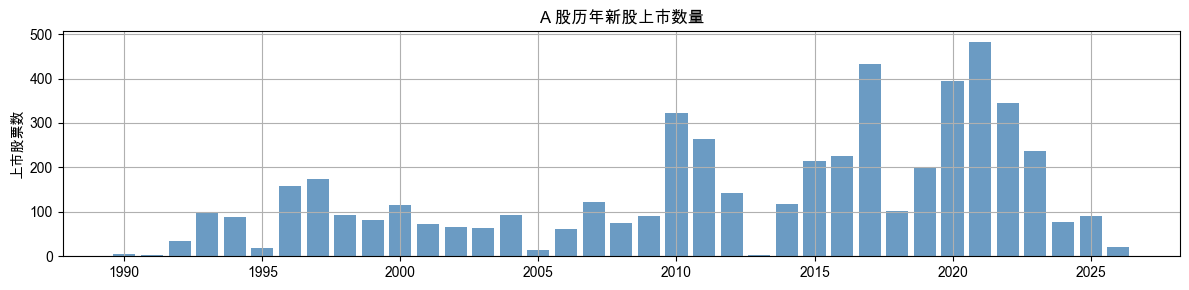

In [19]:
basic = load_stock_basic()
print(f"全市场股票：{len(basic)} 只")

# 沪深分布
sh_count = basic["symbol"].str.endswith(".SH").sum()
sz_count = basic["symbol"].str.endswith(".SZ").sum()
print(f"  沪市（.SH）：{sh_count} 只")
print(f"  深市（.SZ）：{sz_count} 只")

# 历年上市数量
yearly_ipo = basic.set_index("list_date").resample("YE")["symbol"].count()
fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(yearly_ipo.index.year, yearly_ipo.values, color="steelblue", alpha=0.8)
ax.set_title("A 股历年新股上市数量")
ax.set_ylabel("上市股票数")
plt.tight_layout()
plt.show()


## 5. ST 历史过滤

**ST（Special Treatment，特别处理）机制**：

上市公司连续两年亏损或出现重大违规，交易所对其实施特别处理，名称前加"ST"或"*ST"。

**为什么必须剔除 ST 股？**
- 价格行为异常（退市预期、游资炒作）
- 可能被暂停交易，无法执行信号
- 模型在 ST 股上的"预测"本质上是噪声

**关键设计**：必须使用历史 ST 状态，而非当前状态。
用当前状态回溯会引入 look-ahead bias——我们现在知道某股票曾经 ST，但在那个时间点并不知道它之后会摘帽。


ST 历史记录：286 条
涉及股票：55 只（占宇宙 11.0%）
当前仍是 ST：3 只


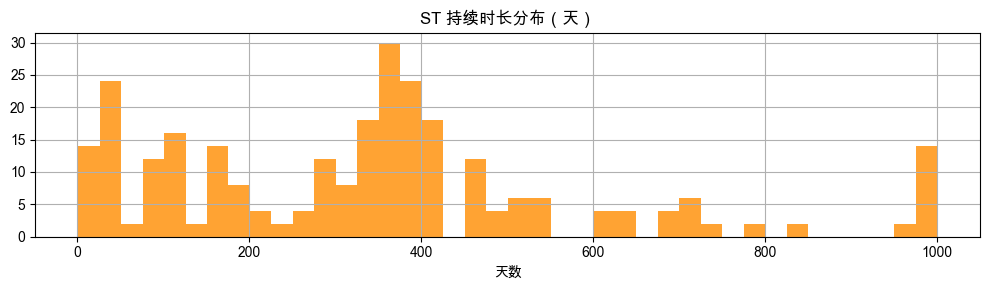

In [20]:
symbols = sorted(set(universe["symbol"]) & set(basic["symbol"]))
st_history = load_st_history(symbols)

print(f"ST 历史记录：{len(st_history)} 条")
print(f"涉及股票：{st_history['symbol'].nunique()} 只（占宇宙 {st_history['symbol'].nunique()/len(symbols):.1%}）")

# 当前仍是 ST 的股票
current_st = st_history[st_history["end_date"].isna()]["symbol"].unique()
print(f"当前仍是 ST：{len(current_st)} 只")

# ST 历史时长分布
st_with_end = st_history.dropna(subset=["end_date"]).copy()
st_with_end["duration_days"] = (st_with_end["end_date"] - st_with_end["start_date"]).dt.days
fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(st_with_end["duration_days"].clip(0, 1000), bins=40, color="darkorange", alpha=0.8)
ax.set_title("ST 持续时长分布（天）")
ax.set_xlabel("天数")
plt.tight_layout()
plt.show()


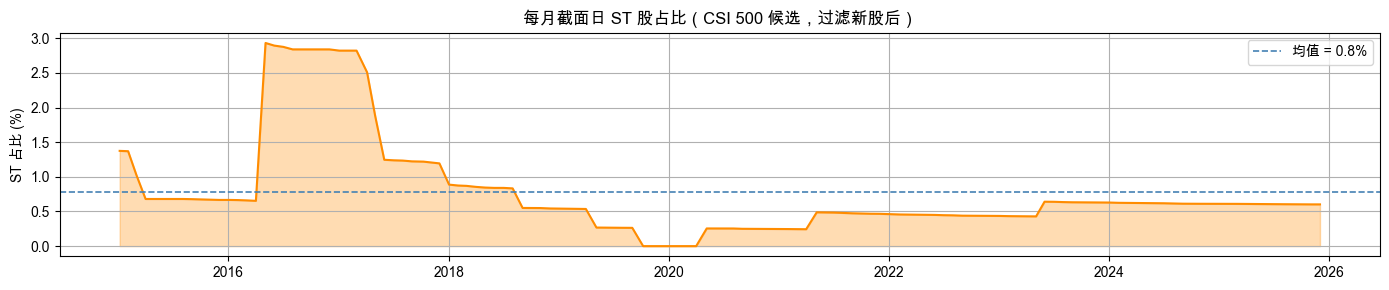

ST 占比：均值 0.8%，最高 2.9%，最低 0.0%


In [21]:
from sp500_relative_alpha.ashare_data_loader import MIN_LISTING_DAYS

st_ratio_records = {}
for d in sample_dates:
    trading_days_before = calendar[calendar < d]
    cutoff = (trading_days_before[-MIN_LISTING_DAYS]
              if len(trading_days_before) >= MIN_LISTING_DAYS else pd.Timestamp("19900101"))
    listed = set(basic[basic["list_date"].notna() & (basic["list_date"] <= cutoff)]["symbol"])
    candidates = set(universe["symbol"]) & listed

    st_on_date = set(
        st_history[
            (st_history["start_date"] <= d) &
            (st_history["end_date"].isna() | (st_history["end_date"] >= d))
        ]["symbol"]
    )
    st_in_candidates = candidates & st_on_date
    st_ratio_records[d] = len(st_in_candidates) / len(candidates) if candidates else 0

st_ratio_series = pd.Series(st_ratio_records)

fig, ax = plt.subplots(figsize=(14, 3))
ax.fill_between(st_ratio_series.index, st_ratio_series.values * 100, alpha=0.3, color="darkorange")
ax.plot(st_ratio_series.index, st_ratio_series.values * 100, color="darkorange", lw=1.5)
ax.axhline(st_ratio_series.mean() * 100, color="steelblue", lw=1.2, linestyle="--",
           label=f"均值 = {st_ratio_series.mean():.1%}")
ax.set_title("每月截面日 ST 股占比（CSI 500 候选，过滤新股后）")
ax.set_ylabel("ST 占比 (%)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"ST 占比：均值 {st_ratio_series.mean():.1%}，最高 {st_ratio_series.max():.1%}，最低 {st_ratio_series.min():.1%}")

## 6. 每日有效宇宙

组合以上所有过滤条件，计算每个 signal_date 的实际可用股票数。

这是构建特征矩阵和截面排名的基础——股票数越稳定，截面信号越可靠。


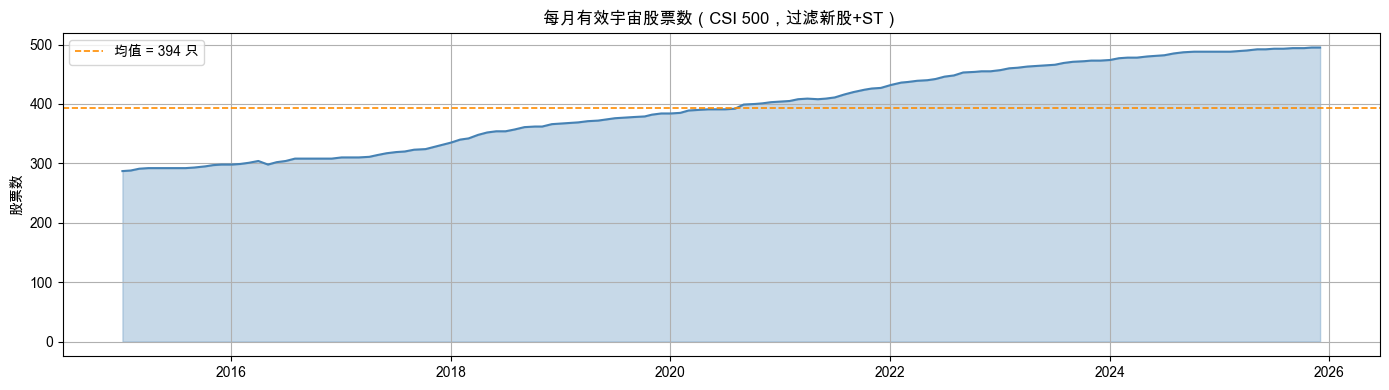

有效宇宙规模：均值 394，最小 287，最大 495


In [22]:
universe_size = {}
for d in sample_dates:
    active = build_daily_universe(d, universe, basic, st_history, calendar)
    universe_size[d] = len(active)

size_series = pd.Series(universe_size)

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(size_series.index, size_series.values, alpha=0.3, color="steelblue")
ax.plot(size_series.index, size_series.values, color="steelblue", lw=1.5)
ax.axhline(size_series.mean(), color="darkorange", lw=1.2, linestyle="--",
           label=f"均值 = {size_series.mean():.0f} 只")
ax.set_title("每月有效宇宙股票数（CSI 500，过滤新股+ST）")
ax.set_ylabel("股票数")
ax.legend()
plt.tight_layout()
plt.show()

print(f"有效宇宙规模：均值 {size_series.mean():.0f}，最小 {size_series.min()}，最大 {size_series.max()}")

## 7. 行业分布

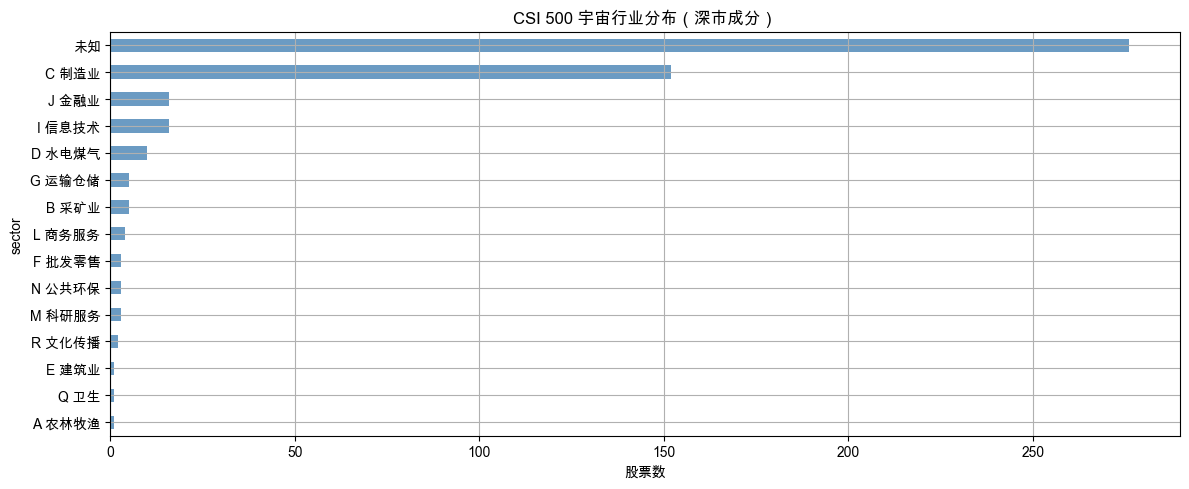

In [23]:
import akshare as ak

# AKShare 获取深市行业分类（已在 stock_basic 里）
sz_info = ak.stock_info_sz_name_code(symbol="A股列表")[["A股代码", "所属行业"]]
sz_info.columns = ["code", "sector"]
sz_info["symbol"] = sz_info["code"].astype(str).str.zfill(6) + ".SZ"

# 映射到宇宙
universe_with_sector = universe.merge(
    sz_info[["symbol", "sector"]], on="symbol", how="left"
)

# 沪市行业信息
sh_info = ak.stock_info_sh_name_code(symbol="主板A股")[["证券代码", "证券简称"]]
# 沪市 AKShare 无行业字段，用证券简称占位

sector_counts = (
    universe_with_sector["sector"]
    .fillna("未知")
    .value_counts()
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 5))
sector_counts.plot(kind="barh", ax=ax, color="steelblue", alpha=0.8)
ax.set_title("CSI 500 宇宙行业分布（深市成分）")
ax.set_xlabel("股票数")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 8. OHLCV 数据概览

前复权公式：`adj_price = raw_price × adj_factor / latest_adj_factor`

最新价格不变，历史价格向下调整，保证价格序列连续（分红、拆股不影响收益率计算）。


OHLCV 数据：1,252,500 行，502 只股票
日期范围：2013-01-04 ~ 2026-04-01
每日平均股票数：390


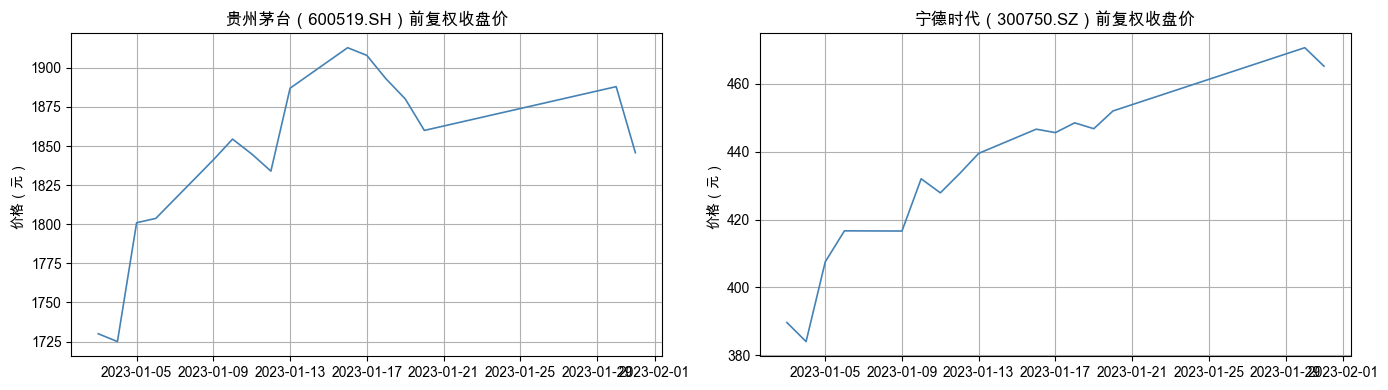

In [24]:
from sp500_relative_alpha.ashare_data_loader import CACHE_DIR

bars = pd.read_parquet(CACHE_DIR / "ohlcv_adj.parquet")
print(f"OHLCV 数据：{len(bars):,} 行，{bars['symbol'].nunique()} 只股票")
print(f"日期范围：{bars['date'].min().date()} ~ {bars['date'].max().date()}")
print(f"每日平均股票数：{bars.groupby('date')['symbol'].count().mean():.0f}")

# 几只代表性股票的价格走势
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for sym, ax, name in [
    ("600519.SH", axes[0], "贵州茅台"),
    ("300750.SZ", axes[1], "宁德时代"),
]:
    s = bars[bars["symbol"] == sym].sort_values("date")
    ax.plot(s["date"], s["close"], lw=1.2, color="steelblue")
    ax.set_title(f"{name}（{sym}）前复权收盘价")
    ax.set_ylabel("价格（元）")

plt.tight_layout()
plt.show()


## 9. 与 S&P 500 的对比

| 维度 | S&P 500 | CSI 500 |
|---|---|---|
| 股票数 | 503 只 | ~450 只（过滤后） |
| 市场 | 美股，机构主导 | A 股，散户参与多 |
| 数据来源 | Databento | Tushare + AKShare |
| 宇宙稳定性 | 高（半年调整一次） | 中（动态近似） |
| 涨跌停制度 | 无 | ±10%（影响标签构造） |
| ST 机制 | 无 | 有（需过滤） |
| 预期 IC 强度 | 弱（市场效率高） | 可能更强（市场效率低） |

**涨跌停对标签的影响**：H=5 的开盘买入/卖出假设在 A 股成立的前提是
entry_date 开盘时股票没有涨停（买不到）或跌停（卖不掉）。
当前版本忽略了这个问题——是已知的近似误差，后续可加涨跌停过滤。

## 10. 下一步

数据层已就绪，可以直接复用现有的特征工程和模型代码：

```python
from sp500_relative_alpha.ashare_data_loader import build_ashare_research_bars
from sp500_relative_alpha.research_dataset import build_v2_research_dataset

bars = build_ashare_research_bars()   # 从缓存读取，秒级
dataset = build_v2_research_dataset(bars, horizons=[5])  # 完全复用
```

特征工程（`ohlcv_features.py`、`feature_transforms.py`）、
模型训练（`modeling.py`）、评估（`metrics.py`）代码**一行不用改**。
